In [3]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [8]:
files = [
    "C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework10/M13_0001.fits", 
    "C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework10/M13_0002.fits", 
    "C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework10/M13_0003.fits", 
    "C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework10/M13_0004.fits", 
    "C:/Users/kevinjfei/python_decal_fa25/course_assignments/homework10/M13_0005.fits", 
]

datas = []
headers = []

for file in files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        datas.append(data)
        headers.append(header)

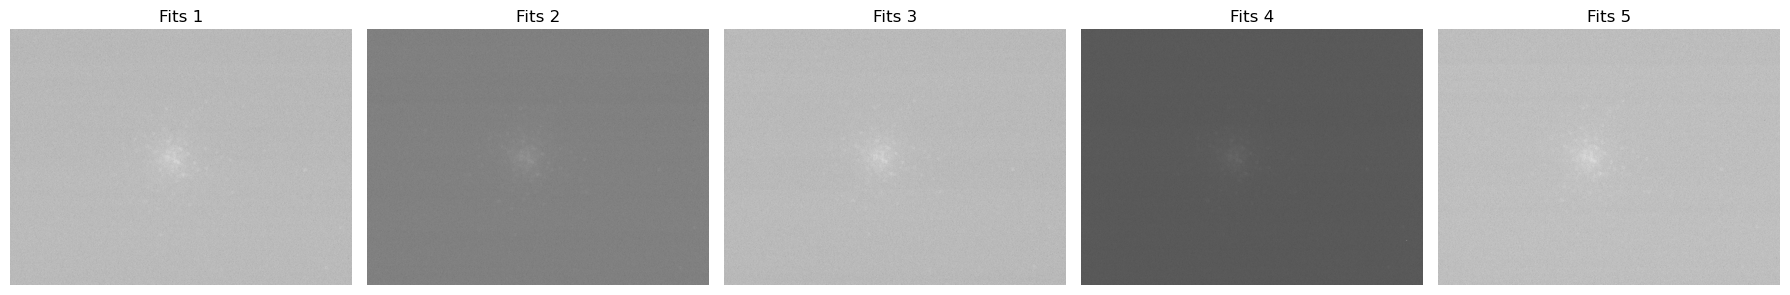

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ax in enumerate(axes):
    ax.imshow(datas[i], origin="lower", cmap="gray")
    ax.set_title(f"Fits {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()


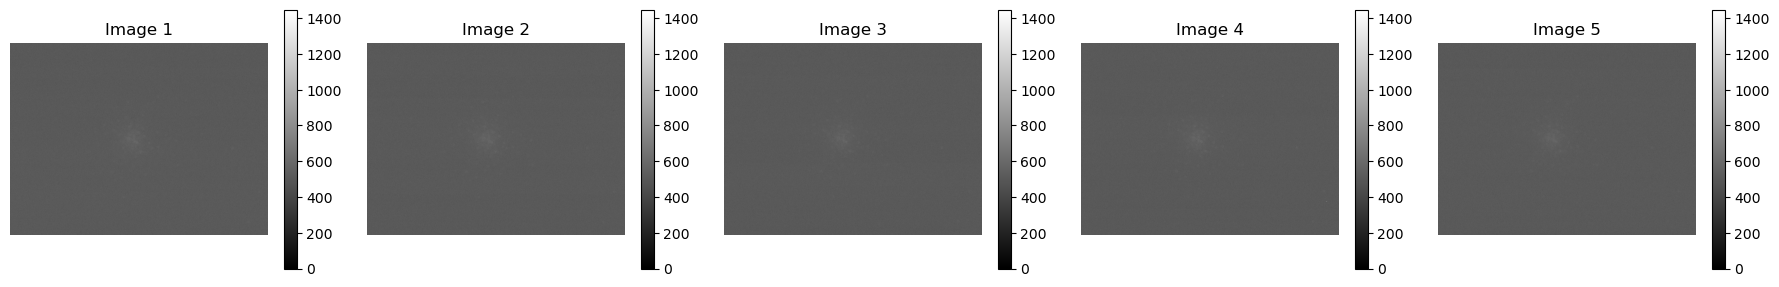

In [6]:
global_vmin = min(data.min() for data in datas)
global_vmax = max(data.max() for data in datas)


fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(datas[i], origin="lower", cmap="gray",
                   vmin=global_vmin, vmax=global_vmax)
    ax.set_title(f"Image {i+1}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()


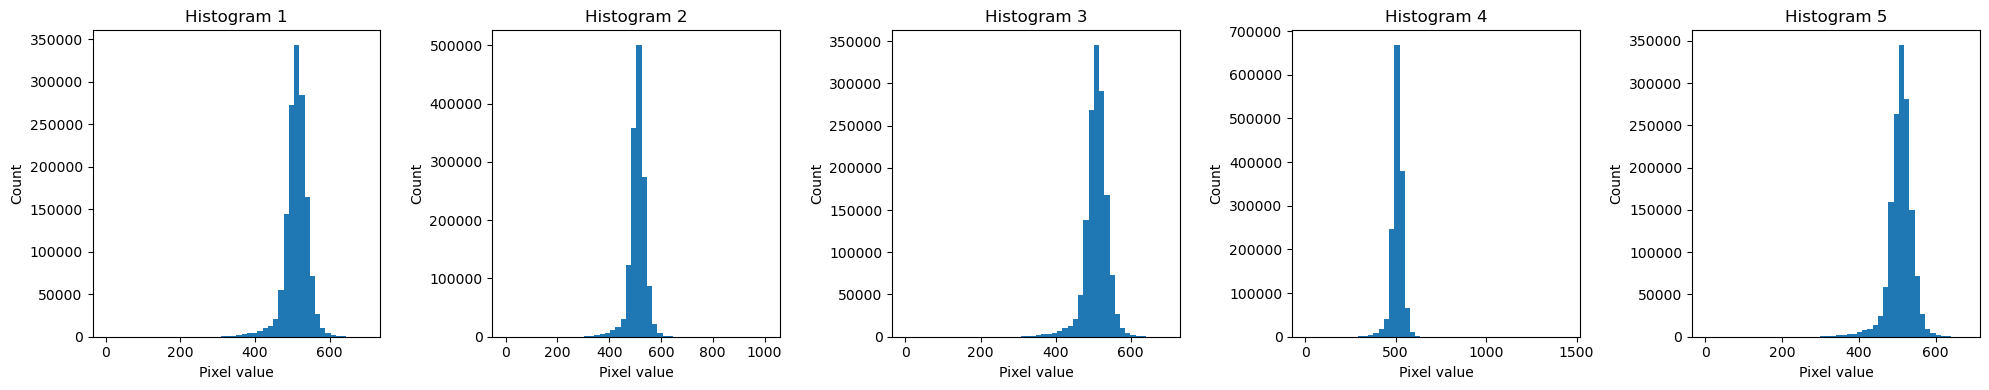

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    flat = datas[i].ravel()
    ax.hist(flat, bins=50) # bins = # per bar on x axis.
    ax.set_title(f"Histogram {i+1}")
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

#seems to be centered at 500
# spread roughly 100 in each direction.

In [11]:
for i, d in enumerate(datas):
    mean_val = np.mean(d)
    median_val = np.median(d)
    print(f"Image {i+1}: mean = {mean_val:.2f}, median = {median_val:.2f}")

Image 1: mean = 510.47, median = 512.00
Image 2: mean = 509.75, median = 511.00
Image 3: mean = 508.05, median = 510.00
Image 4: mean = 507.91, median = 509.00
Image 5: mean = 508.79, median = 510.00


In [13]:
combined_image = np.median(datas, axis=0)
combined_image

array([[494., 480., 519., ..., 490., 531., 522.],
       [518., 513., 489., ..., 513., 498., 498.],
       [500., 516., 514., ..., 520., 498., 530.],
       ...,
       [466., 503., 509., ..., 505., 508., 518.],
       [499., 511., 509., ..., 521., 478., 539.],
       [513., 515., 522., ..., 522., 521., 491.]])

In [14]:
overall_median = np.median(combined_image)
overall_median

np.float64(510.0)

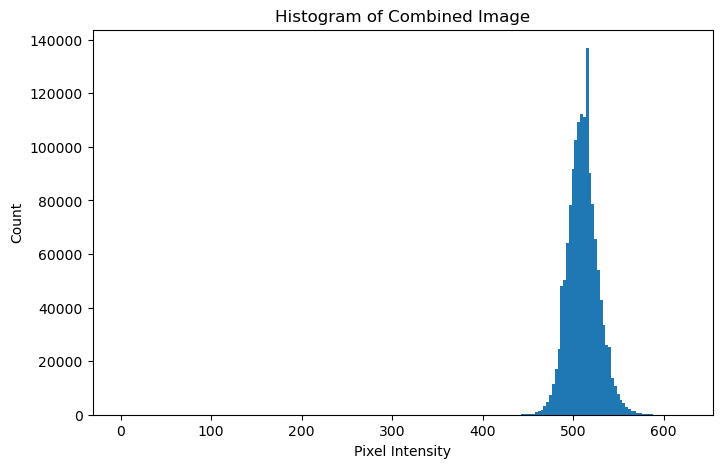

In [15]:
plt.figure(figsize=(8,5))
plt.hist(combined_image.flatten(), bins=200)
plt.title("Histogram of Combined Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.show()

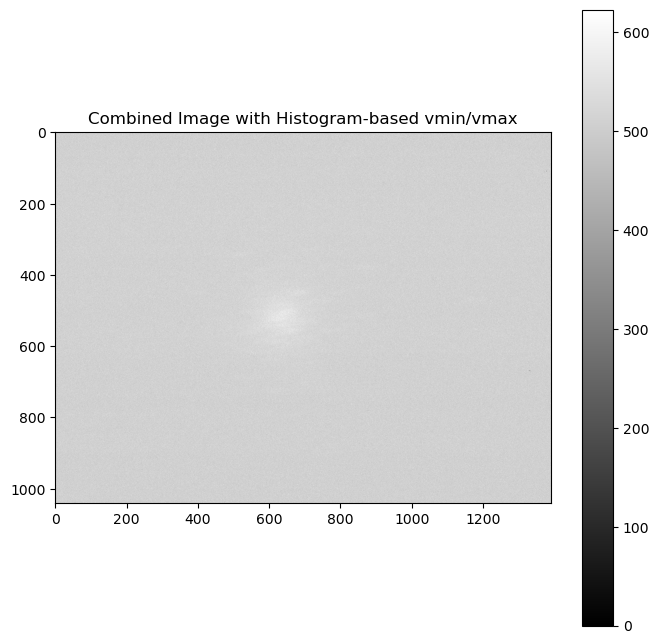

In [16]:
hist_vals, bin_edges = np.histogram(combined_image.flatten(), bins=200)

vmin = bin_edges[0]
vmax = bin_edges[-1]

plt.figure(figsize=(8,8))
plt.imshow(combined_image, cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image with Histogram-based vmin/vmax")
plt.show()
